In [1]:
import os ; import sys
cipath = "/home/joselado/Documents/programs/tranci" # address where the library is
sys.path.append(cipath+"/src")
import matplotlib.pyplot as plt

# Create a crystal field for an atom based on orbital energies
This example shows how you can create a crystal field Hamiltonian from the single particle energies of different cartesian orbitals

In [2]:
from tranci.atom import get_atom

# now generate a new class for an atom with several electrons

ne = 1 # number of electrons

# generate an atom class for the system you want to compute
Atom = get_atom(ne=ne) 

# onsite energies of the different orbitals
dz2,dxy,dx2y2,dxz,dyz = 0.,0.,0.,0.,-0.1

CF = dz2*Atom.SP_Operator["dz2"] + dx2y2*Atom.SP_Operator["dx2y2"] + dxy*Atom.SP_Operator["dxy"]
CF = CF + dyz*Atom.SP_Operator["dyz"] + dxz*Atom.SP_Operator["dxz"]

# this allows you to define any crystal field by using the angular momenta in the single particle basis
CF_MB = Atom.one2many(CF) # crystal field in the many body basis

# total Hamiltonian
H = 4.*Atom.Operator["Coulomb"] + CF_MB # many body Hamiltonian

<BarContainer object of 5 artists>

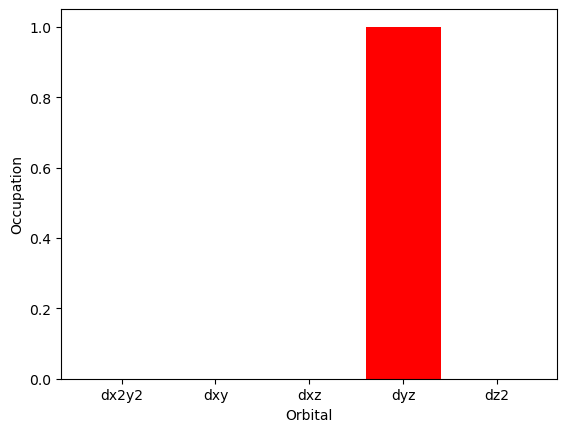

In [3]:
import numpy as np
M = Atom.get_manifolds(H) # get the manifolds object
orbs = ["dx2y2","dxy","dxz","dyz","dz2"] # names of the orbitals
ps = []
for o in orbs: # occupatioon of all the orbitals
    p = np.mean(M.get_gs_projected_eigenvalues(Atom.Operator[o])) # project
    ps.append(p)
plt.ylabel("Occupation") ; plt.xlabel("Orbital")
plt.bar(orbs,ps,color="red")